# 🧩 Reto 4 – Integración final de resultados

**Objetivo:** combinar los resultados de los retos anteriores para obtener un diagnóstico integral de la calidad del agua.

### 🔹 Instrucciones
- Importa los resultados obtenidos en los notebooks anteriores.
- Integra los análisis (pH, temperatura, oxígeno) en un solo DataFrame.
- Realiza una conclusión general del estado del agua.

In [77]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


# Reto 4 - Integración Final y Diagnóstico
**Responsable:** Estudiante 4
**Objetivo:** Consolidar la información analizada por el equipo, agrupar los datos por sitio de muestreo y emitir un diagnóstico integral de la calidad del agua utilizando Pandas.

In [78]:
import pandas as pd

data = {
    "Punto": ["A", "B", "C", "D", "E"],
    "Temp": [22.25, 24.3, 19.8, 23.65, 25.15],
    "pH": [7.15, 7.2, 6.85, 7.05, 7.25],
    "OD_promedio": [6.2, 5.8, 4.9, 6.5, 5.0]
}

df = pd.DataFrame(data)

df

,Punto,Temp,pH,OD_promedio
0,A,22.25,7.15,6.2
1,B,24.30,7.20,5.8
2,C,19.80,6.85,4.9
3,D,23.65,7.05,6.5
4,E,25.15,7.25,5.0


## Integración y Análisis de la Calidad del Agua

En esta sección se realiza la integración de los datos correspondientes a las variables fisicoquímicas del agua, específicamente pH, temperatura y oxígeno disuelto.

A partir de estos datos, se construye un DataFrame que permite organizar la información por puntos de muestreo, facilitando su análisis mediante herramientas de la librería pandas.

El objetivo principal es evaluar la calidad del agua a través de criterios establecidos para cada variable, permitiendo identificar condiciones óptimas, regulares o críticas en los diferentes puntos analizados.

In [79]:
resumen_sitios = df.copy()

In [80]:
resumen_sitios["Diagnostico_Final"] = "Calidad Regular 🟡"

# Condición crítica
resumen_sitios.loc[
    (resumen_sitios["OD_promedio"] < 3) |
    (resumen_sitios["pH"] < 6.0) |
    (resumen_sitios["pH"] > 9.0),
    "Diagnostico_Final"
] = "Calidad Crítica 🔴"

# Condición óptima
resumen_sitios.loc[
    (resumen_sitios["OD_promedio"] >= 5) &
    (resumen_sitios["pH"].between(6.5, 8.5)) &
    (resumen_sitios["Temp"] < 25),
    "Diagnostico_Final"
] = "Calidad Óptima 🟢"

resumen_sitios

,Punto,Temp,pH,OD_promedio,Diagnostico_Final
0,A,22.25,7.15,6.2,Calidad Óptima 🟢
1,B,24.30,7.20,5.8,Calidad Óptima 🟢
2,C,19.80,6.85,4.9,Calidad Regular 🟡
3,D,23.65,7.05,6.5,Calidad Óptima 🟢
4,E,25.15,7.25,5.0,Calidad Regular 🟡


In [81]:
resumen_sitios["Diagnostico_Final"] = "Calidad Regular 🟡"

# Condición crítica
resumen_sitios.loc[
    (resumen_sitios["OD_promedio"] < 3) |
    (resumen_sitios["pH"] < 6.0) |
    (resumen_sitios["pH"] > 9.0),
    "Diagnostico_Final"
] = "Calidad Crítica 🔴"

# Condición óptima
resumen_sitios.loc[
    (resumen_sitios["OD_promedio"] >= 5) &
    (resumen_sitios["pH"].between(6.5, 8.5)) &
    (resumen_sitios["Temp"] < 25),
    "Diagnostico_Final"
] = "Calidad Óptima 🟢"

resumen_sitios

,Punto,Temp,pH,OD_promedio,Diagnostico_Final
0,A,22.25,7.15,6.2,Calidad Óptima 🟢
1,B,24.30,7.20,5.8,Calidad Óptima 🟢
2,C,19.80,6.85,4.9,Calidad Regular 🟡
3,D,23.65,7.05,6.5,Calidad Óptima 🟢
4,E,25.15,7.25,5.0,Calidad Regular 🟡


## Análisis de Resultados

Una vez estructurados los datos, se realiza un análisis utilizando funciones de pandas como `value_counts` y `groupby`, con el fin de identificar patrones en las variables evaluadas.

El diagnóstico final se construye mediante condiciones lógicas aplicadas a los valores de pH, temperatura y oxígeno disuelto, considerando rangos de referencia para determinar la calidad del agua.

Este análisis permite comparar los diferentes puntos de muestreo y reconocer cuáles presentan mejores condiciones y cuáles podrían representar riesgos para el ecosistema acuático.

In [82]:
resumen_sitios["Diagnostico_Final"].value_counts()

Diagnostico_Final
Calidad Óptima 🟢     3
Calidad Regular 🟡    2
Name: count, dtype: int64

In [83]:
resumen_sitios.groupby("Diagnostico_Final")[["pH", "Temp", "OD_promedio"]].mean()

,pH,Temp,OD_promedio
Diagnostico_Final,,,
Calidad Regular 🟡,7.050000,22.475,4.950000
Calidad Óptima 🟢,7.133333,23.400,6.166667


<Figure size 640x480 with 0 Axes>

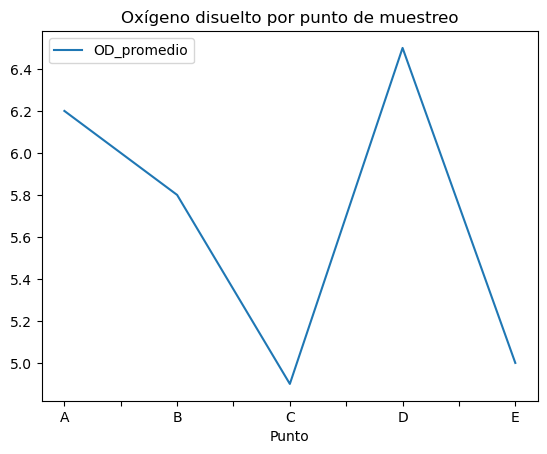

In [84]:
import matplotlib.pyplot as plt

plt.figure()
resumen_sitios.plot(x="Punto", y="OD_promedio")
plt.title("Oxígeno disuelto por punto de muestreo")
plt.show()

In [85]:
resumen_sitios.sort_values(by="OD_promedio")

,Punto,Temp,pH,OD_promedio,Diagnostico_Final
2,C,19.80,6.85,4.9,Calidad Regular 🟡
4,E,25.15,7.25,5.0,Calidad Regular 🟡
1,B,24.30,7.20,5.8,Calidad Óptima 🟢
0,A,22.25,7.15,6.2,Calidad Óptima 🟢
3,D,23.65,7.05,6.5,Calidad Óptima 🟢


In [86]:
resumen_sitios["Diagnostico_Final"].value_counts()

Diagnostico_Final
Calidad Óptima 🟢     3
Calidad Regular 🟡    2
Name: count, dtype: int64

## Conclusiones

A partir del análisis realizado, se observa que la mayoría de los puntos de muestreo presentan condiciones de calidad de agua entre óptimas y regulares, lo que indica un estado general aceptable del sistema.

Sin embargo, se identifican variaciones en el oxígeno disuelto, particularmente en el punto C, donde se registran valores más bajos, lo que podría generar condiciones de estrés para los organismos acuáticos.

Asimismo, se evidencian temperaturas ligeramente elevadas en algunos puntos, lo que puede influir en la disponibilidad de oxígeno en el agua.

En general, aunque no se presentan condiciones críticas, es importante realizar un monitoreo constante para prevenir posibles deterioros en la calidad del agua y asegurar la sostenibilidad del ecosistema.

## Visualizacion de Datos

In [87]:
import matplotlib.pyplot as plt

In [88]:
import pandas as pd

In [89]:
import os
os.getcwd()

'c:\\Users\\kncar\\3-introduccion-al-almacenacenamiento-de-datos-2026__2_mariajose-1\\notebooks'

In [90]:
os.listdir()

['0_ejemplo_clase_pandas.ipynb',
 'reto1_lectura_datos.ipynb',
 'reto2_filtros_pandas.ipynb',
 'reto3_funciones_estadisticas.ipynb',
 'reto4_integracion_final.ipynb']

In [91]:
import pandas as pd

data = {
    "Punto": ["A", "B", "C", "D", "E"],
    "Temp": [22.25, 24.3, 19.8, 23.65, 25.15],
    "pH": [7.15, 7.2, 6.85, 7.05, 7.25],
    "OD_promedio": [6.2, 5.8, 4.9, 6.5, 5.0]
}

df = pd.DataFrame(data)

df

,Punto,Temp,pH,OD_promedio
0,A,22.25,7.15,6.2
1,B,24.30,7.20,5.8
2,C,19.80,6.85,4.9
3,D,23.65,7.05,6.5
4,E,25.15,7.25,5.0


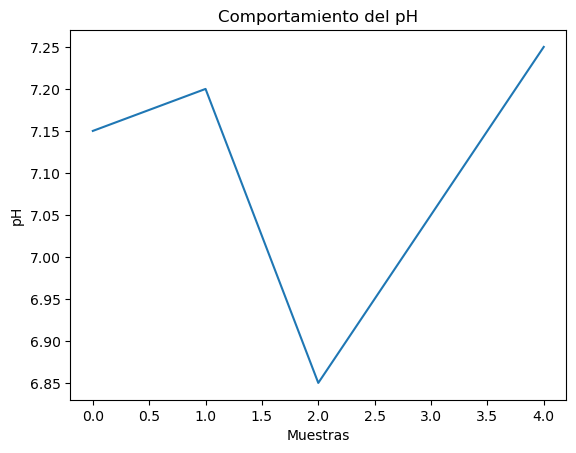

In [92]:
plt.figure()
df["pH"].plot()
plt.title("Comportamiento del pH")
plt.xlabel("Muestras")
plt.ylabel("pH")
plt.show()

El pH presenta valores cercanos a la neutralidad (alrededor de 7), lo cual indica condiciones adecuadas para la vida acuatica. Sin embargo, se observa una ligera disminucion en una de las muestras, lo que podria indicar en la calidad del agua

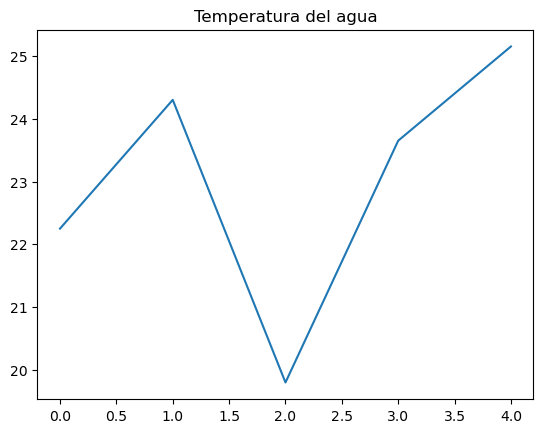

In [93]:
plt.figure()
df["Temp"].plot()
plt.title("Temperatura del agua")
plt.show()

La temperatura del agua muestra variaciones entre aproximadamente 20°C y 25°C.Estos cambios pueden influir en otros parametros como el oxigeno disuelto, ya que a mayor temperatura disminuye su solubilidad.

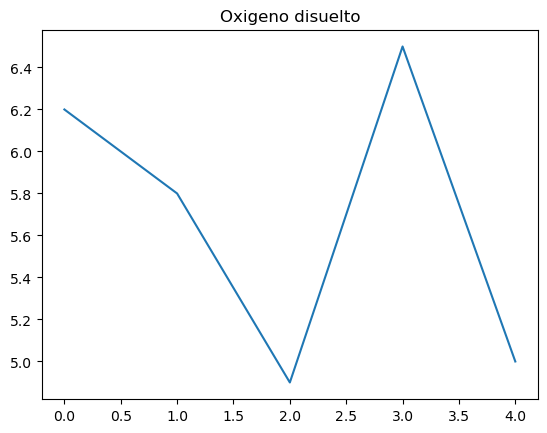

In [94]:
plt.figure()
df["OD_promedio"].plot()
plt.title("Oxigeno disuelto")
plt.show()

El oxigeno disuelto presenta valores variables, con una disminucion notables en algunas muestras. Esto puede afectar negativamente la vida acuatica, ya que niveles bajos de oxigeno pueden generar estres en los organismos.

## Analisis de resultados 

Se observa una relacion entre la temperatura y el oxigeno disuelto, donde al aunmentar la temperatura, los niveles de oxigeno tienden a disminuir. Ademas,aunque el pH se mantiene relativamente estables, las variaciones en oxigeno indican posibles cambios en la calidad del agua.

## Conclusion Graficas
A partir del análisis realizado, se concluye que la calidad del agua es variable. El pH se mantiene dentro de rangos adecuados, sin embargo, los niveles de oxígeno presentan disminuciones en algunas muestras, lo que podría afectar la vida acuática. La temperatura influye en este comportamiento, reduciendo la solubilidad del oxígeno. Se recomienda realizar monitoreo continuo.

## Integración y Evaluación de la Calidad del Agua

En esta sección se integran las variables fisicoquímicas obtenidas en los análisis previos (pH, temperatura y oxígeno disuelto) en un único DataFrame. 

El objetivo es evaluar la calidad del agua mediante el uso de herramientas de la librería pandas, aplicando procesos de limpieza, exploración y análisis de datos. 

Se emplean criterios basados en rangos aceptables para cada variable, con el fin de clasificar las condiciones del agua en categorías como óptima, regular o crítica.

In [95]:
# Resumen general de todas las variables
resumen_general = df.describe().round(2)
resumen_general

,Temp,pH,OD_promedio
count,5.00,5.00,5.00
mean,23.03,7.10,5.68
std,2.09,0.16,0.71
min,19.80,6.85,4.90
25%,22.25,7.05,5.00
50%,23.65,7.15,5.80
75%,24.30,7.20,6.20
max,25.15,7.25,6.50


In [96]:
df[["pH", "Temp", "OD_promedio"]].corr()

,pH,Temp,OD_promedio
pH,1.000000,0.893044,0.199852
Temp,0.893044,1.000000,0.223547
OD_promedio,0.199852,0.223547,1.000000


In [97]:
# Punto con menor oxígeno
df.loc[df["OD_promedio"].idxmin()]

# Punto con mayor temperatura
df.loc[df["Temp"].idxmax()]

# Punto más equilibrado (ejemplo simple)
df.loc[df["OD_promedio"].idxmax()]

Punto              D
Temp           23.65
pH              7.05
OD_promedio      6.5
Name: 3, dtype: object

In [98]:
df.sort_values(by="OD_promedio")

,Punto,Temp,pH,OD_promedio
2,C,19.80,6.85,4.9
4,E,25.15,7.25,5.0
1,B,24.30,7.20,5.8
0,A,22.25,7.15,6.2
3,D,23.65,7.05,6.5


## Conclusión Final

El análisis integrado de las variables fisicoquímicas permite concluir que la calidad del agua en los puntos evaluados es en general adecuada, aunque presenta variaciones que deben ser monitoreadas.

Se identificó que el punto C presenta menores niveles de oxígeno disuelto, lo que podría afectar la vida acuática si las condiciones persisten. Por otro lado, algunos puntos presentan temperaturas más elevadas, lo cual puede influir negativamente en la disponibilidad de oxígeno.

En términos generales, no se evidencian condiciones críticas, pero sí la necesidad de mantener un seguimiento constante para prevenir posibles alteraciones en el equilibrio del ecosistema acuático.